In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e2/sample_submission.csv
/kaggle/input/playground-series-s5e2/train.csv
/kaggle/input/playground-series-s5e2/test.csv
/kaggle/input/playground-series-s5e2/training_extra.csv


In [2]:
!pip install cmaes

In [3]:
!pip install --upgrade optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 6.2 MB/s eta 0:00:00
  Attempting uninstall: optuna
    Found existing installation: optuna 4.2.0
    Uninstalling optuna-4.2.0:
      Successfully uninstalled optuna-4.2.0


In [4]:
!pip install --upgrade scikit-learn==1.4 --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 171.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2


In [5]:
#all import
import pandas as pd
import numpy as np
from functools import partial
from copy import deepcopy
import gc
import matplotlib.pyplot as plt
import seaborn as sns

# Import libraries for gradient boosting
import optuna
from optuna.samplers import CmaEsSampler
from sklearn.base import BaseEstimator, TransformerMixin
import xgboost as xgb
import lightgbm as lgb
# from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, GradientBoostingRegressor
# from sklearn.svm import NuSVC, SVC
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.linear_model import LogisticRegression
# from sklearn.neural_network import MLPRegressor
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF
from catboost import CatBoost, CatBoostRegressor, CatBoostRegressor
from catboost import Pool
from category_encoders import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import root_mean_squared_error, log_loss
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, KFold


In [6]:
#read data 
df_train=pd.read_csv('/kaggle/input/playground-series-s5e2/train.csv')
df_train_xtra=pd.read_csv('/kaggle/input/playground-series-s5e2/training_extra.csv')
df_test=pd.read_csv('/kaggle/input/playground-series-s5e2/test.csv')
df_sub=pd.read_csv('/kaggle/input/playground-series-s5e2/sample_submission.csv')

In [7]:
missing_weight_ids=df_test[df_test['Weight Capacity (kg)'].isna()].id.values

In [8]:
df_train.id.values.max()

299999

In [9]:
#See all columns
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    300000 non-null  int64  
 1   Brand                 290295 non-null  object 
 2   Material              291653 non-null  object 
 3   Size                  293405 non-null  object 
 4   Compartments          300000 non-null  float64
 5   Laptop Compartment    292556 non-null  object 
 6   Waterproof            292950 non-null  object 
 7   Style                 292030 non-null  object 
 8   Color                 290050 non-null  object 
 9   Weight Capacity (kg)  299862 non-null  float64
 10  Price                 300000 non-null  float64
dtypes: float64(3), int64(1), object(7)
memory usage: 25.2+ MB


In [10]:
df_train_xtra.id.values.max()

4194317

In [11]:
df_train_xtra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3694318 entries, 0 to 3694317
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   Brand                 object 
 2   Material              object 
 3   Size                  object 
 4   Compartments          float64
 5   Laptop Compartment    object 
 6   Waterproof            object 
 7   Style                 object 
 8   Color                 object 
 9   Weight Capacity (kg)  float64
 10  Price                 float64
dtypes: float64(3), int64(1), object(7)
memory usage: 310.0+ MB


In [12]:
df_train=pd.concat([df_train,df_train_xtra])

In [13]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3994318 entries, 0 to 3694317
Data columns (total 11 columns):
 #   Column                Dtype  
---  ------                -----  
 0   id                    int64  
 1   Brand                 object 
 2   Material              object 
 3   Size                  object 
 4   Compartments          float64
 5   Laptop Compartment    object 
 6   Waterproof            object 
 7   Style                 object 
 8   Color                 object 
 9   Weight Capacity (kg)  float64
 10  Price                 float64
dtypes: float64(3), int64(1), object(7)
memory usage: 365.7+ MB


In [14]:
df_train[df_train['id']>299999]

,id,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,500000,Under Armour,Canvas,Small,10.0,Yes,Yes,Tote,Blue,23.882052,114.11068
1,500001,Puma,Polyester,Small,4.0,No,Yes,Backpack,Green,11.869095,129.74972
2,500002,Jansport,Polyester,Small,8.0,Yes,Yes,Tote,Red,8.092302,21.37370
3,500003,Nike,Nylon,Large,7.0,No,No,Messenger,Pink,7.719581,48.09209
4,500004,Nike,Leather,Large,9.0,No,Yes,Tote,Green,22.741826,77.32461
...,...,...,...,...,...,...,...,...,...,...,...
3694313,4194313,Nike,Canvas,NaN,3.0,Yes,Yes,Messenger,Blue,28.098120,104.74460
3694314,4194314,Puma,Leather,Small,10.0,Yes,Yes,Tote,Blue,17.379531,122.39043
3694315,4194315,Jansport,Canvas,Large,10.0,No,No,Backpack,Red,17.037708,148.18470
3694316,4194316,Puma,Canvas,NaN,2.0,No,No,Backpack,Gray,28.783339,22.32269


In [15]:
df_train.isna().any()

id                      False
Brand                    True
Material                 True
Size                     True
Compartments            False
Laptop Compartment       True
Waterproof               True
Style                    True
Color                    True
Weight Capacity (kg)     True
Price                   False
dtype: bool

In [16]:
df_train=df_train.rename(columns={'Laptop Compartment':'Laptop_Compartment','Weight Capacity (kg)':'Weight_Capacity_(kg)'})
df_test=df_test.rename(columns={'Laptop Compartment':'Laptop_Compartment','Weight Capacity (kg)':'Weight_Capacity_(kg)'})

In [17]:
for c in df_train.columns:
    if c not in ['id','Compartments','Price']:
        if df_train[c].dtype==np.number:
            print(f'col {c}\t{df_train[c].min()},{df_train[c].max()},{df_train[c].mean()}')
        else:
            print(f'col {c}\t{df_train[c].unique()}')

<ipython-input-17-8652e0be35bb>:3: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  if df_train[c].dtype==np.number:


col Brand	['Jansport' 'Under Armour' 'Nike' 'Adidas' 'Puma' nan]
col Material	['Leather' 'Canvas' 'Nylon' nan 'Polyester']
col Size	['Medium' 'Small' 'Large' nan]
col Laptop_Compartment	['Yes' 'No' nan]
col Waterproof	['No' 'Yes' nan]
col Style	['Tote' 'Messenger' nan 'Backpack']
col Color	['Black' 'Green' 'Red' 'Blue' 'Gray' 'Pink' nan]
col Weight_Capacity_(kg)	5.0,30.0,18.0104168149865


In [18]:
for c in df_test.columns:
    if c not in ['id','Compartments','Price']:
        if df_test[c].dtype==np.number:
            print(f'col {c}\t{df_test[c].min()},{df_test[c].max()},{df_test[c].mean()}')
        else:
            print(f'col {c}\t{df_test[c].unique()}')

col Brand	['Puma' 'Nike' 'Adidas' nan 'Under Armour' 'Jansport']
col Material	['Leather' 'Canvas' 'Nylon' 'Polyester' nan]
col Size	['Small' 'Medium' 'Large' nan]
col Laptop_Compartment	['No' 'Yes' nan]
col Waterproof	['No' 'Yes' nan]
col Style	['Tote' 'Backpack' 'Messenger' nan]
col Color	['Green' 'Blue' 'Black' 'Red' 'Pink' 'Gray' nan]
col Weight_Capacity_(kg)	5.0,30.0,17.993033231213683


<ipython-input-18-fc51ea396d26>:3: DeprecationWarning: Converting `np.inexact` or `np.floating` to a dtype is deprecated. The current result is `float64` which is not strictly correct.
  if df_test[c].dtype==np.number:


In [19]:
#bag that has no weight values counts
df_train['Weight_Capacity_(kg)'].isna().value_counts()

Weight_Capacity_(kg)
False    3992510
True        1808
Name: count, dtype: int64

In [20]:
#One Hot encoder 
object_columns= df_train.select_dtypes('object').columns.to_list()
encoder = OneHotEncoder(cols=object_columns)
train_encoder = encoder.fit_transform(df_train[object_columns]).astype(int).add_suffix('_ohe')
test_encoder = encoder.transform(df_test[object_columns]).astype(int).add_suffix('_ohe')

In [21]:
#Drop original cols 
df_train=df_train.drop(object_columns,axis=1)
df_train=pd.concat([df_train,train_encoder],axis=1)

df_test=df_test.drop(object_columns,axis=1)
df_test=pd.concat([df_test,test_encoder],axis=1)


In [22]:
#waterproof_2_ohe is Yes
#Laptop_Compartment_1_ohe
# Blue Black Red 4 1 3


In [23]:
df_train=df_train.dropna()
#df_test=df_test.dropna()

In [24]:
df_train=df_train.drop('id',axis=1)
#df_test=df_test.drop('id',axis=1)

In [25]:
sc = StandardScaler()
df_train[['Weight_Capacity_(kg)']] = sc.fit_transform(df_train[['Weight_Capacity_(kg)']])
df_test[['Weight_Capacity_(kg)']] = sc.transform(df_test[['Weight_Capacity_(kg)']])

In [26]:
#Create input and label for predict missing weights
X_train_w=df_train.copy()
X_train_w=X_train_w.dropna()
y_train_w=X_train_w['Weight_Capacity_(kg)']
X_train_w=X_train_w.drop(['Price','Weight_Capacity_(kg)'],axis=1)

X_test_w=df_test[df_test['Weight_Capacity_(kg)'].isna()].drop(['id','Weight_Capacity_(kg)'],axis=1)  #73 row

In [27]:
X_train=df_train
y_train=df_train['Price']
X_test=df_test
X_test=X_test.drop('id',axis=1)

In [28]:
X_train=X_train.drop('Price',axis=1)

In [29]:
X_train.Compartments.value_counts()

Compartments
1.0     423158
4.0     417042
2.0     407873
3.0     406578
7.0     400723
5.0     399305
9.0     398054
10.0    396135
8.0     383065
6.0     360577
Name: count, dtype: int64

In [30]:
X_test.Compartments.value_counts()

Compartments
1.0     21203
4.0     20788
3.0     20366
7.0     20103
2.0     20079
5.0     20049
10.0    19850
9.0     19752
8.0     19433
6.0     18377
Name: count, dtype: int64

In [31]:
X_test.shape

(200000, 34)

# Exploratory Data Analysis

In [32]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3992510 entries, 0 to 3694317
Data columns (total 35 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Compartments              float64
 1   Weight_Capacity_(kg)      float64
 2   Price                     float64
 3   Brand_1_ohe               int64  
 4   Brand_2_ohe               int64  
 5   Brand_3_ohe               int64  
 6   Brand_4_ohe               int64  
 7   Brand_5_ohe               int64  
 8   Brand_6_ohe               int64  
 9   Material_1_ohe            int64  
 10  Material_2_ohe            int64  
 11  Material_3_ohe            int64  
 12  Material_4_ohe            int64  
 13  Material_5_ohe            int64  
 14  Size_1_ohe                int64  
 15  Size_2_ohe                int64  
 16  Size_3_ohe                int64  
 17  Size_4_ohe                int64  
 18  Laptop_Compartment_1_ohe  int64  
 19  Laptop_Compartment_2_ohe  int64  
 20  Laptop_Compartment_3_ohe  int

# Optuna

In [33]:
class Regressor:
    def __init__(self, early_stopping_rounds,n_estimators=100, device="cpu", random_state=0):
        self.n_estimators = n_estimators
        self.device = device
        self.random_state = random_state
        self.early_stopping_rounds=early_stopping_rounds
        self.models = self._define_model()
        self.len_models = len(self.models)
        
    def _define_model(self):
        
        xgb_params = {
            'n_estimators': self.n_estimators,
            'learning_rate': 0.05,
            'max_depth': 7,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'n_jobs': -1,
            'eval_metric': 'rmse',
            'objective': 'reg:squarederror',
            'verbosity': 0,
            'reg_alpha': 0.1,  # L1 regularization (lasso)
            'reg_lambda': 1.0,  # L2 regularization (ridge)
            'min_child_weight': 5,  # Prevents learning from small/noisy samples
            'random_state': self.random_state,
            'early_stopping_rounds': self.early_stopping_rounds
        }
        if self.device == 'gpu':
            xgb_params['tree_method'] = 'gpu_hist'
            xgb_params['predictor'] = 'gpu_predictor'
        
        lgb_params = {
            'n_estimators': self.n_estimators,
            'learning_rate': 0.05,
            'num_leaves': 31,  # Controls tree complexity
            'max_depth': -1,  # Let LightGBM decide based on num_leaves
            'subsample': 0.8,  # Helps generalization
            'colsample_bytree': 0.8,  # Uses 80% of features per tree
            'reg_alpha': 0.25,  # L1 regularization (unchanged)
            'reg_lambda': 1.0,  # L2 regularization (adjusted from 5e-08)
            'objective': 'regression',  # Correct for regression tasks
            'metric': 'rmse',  # Regression evaluation metric
            'boosting_type': 'gbdt',  # Gradient Boosting Decision Tree
            'device': self.device,  # Enables GPU if set to 'gpu'
            'random_state': self.random_state,  # Ensures reproducibility
            'early_stopping_rounds': self.early_stopping_rounds,  # Prevents overfitting
           # 'min_child_samples': 20,  # Prevents overfitting on small samples
           # 'importance_type': 'gain'  # Better feature importance calculation
        }
        
        cb_params = {
            'iterations': self.n_estimators,
            'depth': 7,
            'max_bin':200,
            'learning_rate': 0.05,
            'l2_leaf_reg': 0.7,
            'random_strength': 0.2,
            'grow_policy': 'Depthwise',
            'bootstrap_type': 'MVS',
            'eval_metric': 'RMSE',
            'loss_function': 'RMSE',
            'task_type': self.device.upper(),
            'random_state': self.random_state
        }
        
        models = {
            'xgb': xgb.XGBRegressor(**xgb_params),
            'lgb': lgb.LGBMRegressor(**lgb_params),
            'cat': CatBoostRegressor(**cb_params),
        }
        
        return models

In [34]:
class OptunaWeights:
    def __init__(self, random_state):
        self.study = None
        self.weights = None
        self.random_state = random_state

    def _objective(self, trial, y_true, y_preds):
        # Define the weights for the predictions from each model
        weights = [trial.suggest_float(f"weight{n}", 0.0001, 1) for n in range(len(y_preds))]

        # Calculate the weighted prediction
        weighted_pred = np.average(np.array(y_preds).T, axis=1, weights=weights)

        # Calculate the AUC score for the weighted prediction
        score = root_mean_squared_error(y_true, weighted_pred)
        return score

    def fit(self, y_true, y_preds, n_trials=1000):
        optuna.logging.set_verbosity(optuna.logging.ERROR)
        sampler = optuna.samplers.CmaEsSampler(seed=self.random_state)
        self.study = optuna.create_study(sampler=sampler, study_name="OptunaWeights", direction='minimize')
        objective_partial = partial(self._objective, y_true=y_true, y_preds=y_preds)
        self.study.optimize(objective_partial, n_trials=n_trials)
        self.weights = [self.study.best_params[f"weight{n}"] for n in range(len(y_preds))]

    def predict(self, y_preds):
        assert self.weights is not None, 'OptunaWeights error, must be fitted before predict'
        weighted_pred = np.average(np.array(y_preds).T, axis=1, weights=self.weights)
        return weighted_pred

    def fit_predict(self, y_true, y_preds, n_trials=1000):
        self.fit(y_true, y_preds, n_trials=n_trials)
        return self.predict(y_preds)
    
    def weights(self):
        return self.weights
    
#Regression doesn't need ThresholdOptimizer
class ThresholdOptimizer:
    def __init__(self, y_true, y_preds, random_state):
        self.y_true = y_true
        self.y_preds = y_preds
        self.random_state = random_state
        self.sampler = optuna.samplers.CmaEsSampler(seed=self.random_state)
        self.study = optuna.create_study(sampler=self.sampler, study_name="OptunaWeights", direction='maximize')
        self.objective_partial = partial(self._objective, y_true=y_true, y_preds=y_preds)
        
    def _objective(self, trial, y_true, y_preds):
        threshold = trial.suggest_float("threshold", 0, 1)
        score = root_mean_squared_error(y_true, np.where(y_preds > threshold, 1, 0))
        return score
        
    def run_optimization(self, n_trials=1000):
        optuna.logging.set_verbosity(optuna.logging.ERROR)
        self.study.optimize(self.objective_partial, n_trials=n_trials)
        
    def get_best_threshold(self):
        return self.study.best_params["threshold"]

# Training

In [35]:
#TRain to find missing weights
n_splits = 5
random_state = 42
n_estimators = 5000 # 9999
early_stopping_rounds = 50
verbose = False
device = 'cpu'

# Initialize an array for storing test predictions
test_predss = np.zeros(X_test.shape[0])

test_predss_sub = []
ensemble_score = []
weights = []
regressor=Regressor(early_stopping_rounds=early_stopping_rounds)
trained_models = dict(zip(regressor.models.keys(), [[] for _ in range(regressor.len_models)]))

stratify_column=X_train['Compartments']

kf = StratifiedKFold(n_splits=n_splits, random_state=random_state, shuffle=True)
for i, (train_index, val_index) in enumerate(kf.split(X_train_w, stratify_column)):
    X_train_, X_val = X_train_w.iloc[train_index], X_train_w.iloc[val_index]
    y_train_, y_val = y_train_w.iloc[train_index], y_train_w.iloc[val_index]
        
    # Get a set of Regressor models
    rs = Regressor(early_stopping_rounds,n_estimators, device, random_state)
    models = rs.models
    
    # Initialize lists to store oof and test predictions for each base model
    oof_preds = []
    test_preds = []
    
    # Loop over each base model and fit it to the training data, evaluate on validation data, and store predictions
    for name, model in models.items():
        if name == 'cat_label':
            train_pool = Pool(X_train_, y_train_)#, cat_features=categorical_columns)
            test_pool = Pool(X_val, y_val)# ,cat_features=categorical_columns)
            model.fit(train_pool, eval_set=[test_pool], early_stopping_rounds=early_stopping_rounds, verbose=verbose)
        elif name == 'lgb_label':
            model.fit(X_train_, y_train_, eval_set=[(X_val, y_val)])
        elif name in ['xgb', 'lgb', 'cat']:
            model.fit(X_train_, y_train_, eval_set=[(X_val, y_val)])
        else:
            model.fit(X_train_fillna.iloc[train_index], y_train_)
        
        
        # if name in ['xgb', 'lgb', 'cat', 'cat_label', 'lgb_label']:
        #     test_pred = model.predict_proba(X_test)[:, 1]
        #     y_val_pred = model.predict_proba(X_val)[:, 1]
        # else:
        #     test_pred = model.predict_proba(X_test_fillna)[:, 1]
        #     y_val_pred = model.predict_proba(X_train_fillna.iloc[val_index])[:, 1]
        
        test_pred=model.predict(X_test_w)
        y_val_pred=model.predict(X_val)
        score = root_mean_squared_error(y_val, y_val_pred)
        print(f'{name} model [FOLD-{i}] RMSE: {score:.5f}')
        
        oof_preds.append(y_val_pred)
        test_preds.append(test_pred)
        trained_models[f'{name}'].append(deepcopy(model))
    
    # Use Optuna to find the best ensemble weights
    optweights = OptunaWeights(random_state=random_state)
    y_val_pred = optweights.fit_predict(y_val.values, oof_preds)

    #****** Not use Threshold because we do regression *****
    # Use Optuna to find the best threshold
    # opt = ThresholdOptimizer(y_val, y_val_pred, random_state)
    # opt.run_optimization(n_trials=2000)
    # best_threshold = opt.get_best_threshold()
    
    #score = accuracy_score(y_val, np.where(y_val_pred > best_threshold, 1, 0)) 
    score = root_mean_squared_error(y_val, y_val_pred)
    print(f'Ensemble [FOLD-{i}] RMSE score {score:.5f}')
    ensemble_score.append(score)
    weights.append(optweights.weights)
    
    test_predss_sub.append(optweights.predict(test_preds))
    print(f'result added {len(test_predss_sub)} items')
    #test_predss_onehot.append(np.where(optweights.predict(test_preds) > best_threshold, 1, 0))
    gc.collect()

[0]	validation_0-rmse:0.99947
[1]	validation_0-rmse:0.99945
[2]	validation_0-rmse:0.99943
[3]	validation_0-rmse:0.99941
[4]	validation_0-rmse:0.99940
[5]	validation_0-rmse:0.99939
[6]	validation_0-rmse:0.99937
[7]	validation_0-rmse:0.99935
[8]	validation_0-rmse:0.99934
[9]	validation_0-rmse:0.99932
[10]	validation_0-rmse:0.99931
[11]	validation_0-rmse:0.99931
[12]	validation_0-rmse:0.99929
[13]	validation_0-rmse:0.99929
[14]	validation_0-rmse:0.99928
[15]	validation_0-rmse:0.99928
[16]	validation_0-rmse:0.99927
[17]	validation_0-rmse:0.99926
[18]	validation_0-rmse:0.99925
[19]	validation_0-rmse:0.99925
[20]	validation_0-rmse:0.99924
[21]	validation_0-rmse:0.99924
[22]	validation_0-rmse:0.99923
[23]	validation_0-rmse:0.99923
[24]	validation_0-rmse:0.99923
[25]	validation_0-rmse:0.99922
[26]	validation_0-rmse:0.99922
[27]	validation_0-rmse:0.99921
[28]	validation_0-rmse:0.99921
[29]	validation_0-rmse:0.99921
[30]	validation_0-rmse:0.99921
[31]	validation_0-rmse:0.99920
[32]	validation_0-

In [36]:
#The missing weight capacity
#np.median(test_predss_sub, axis=0).reshape(-1,1).flatten()

In [37]:
X_test.isna().any()

Compartments                False
Weight_Capacity_(kg)         True
Brand_1_ohe                 False
Brand_2_ohe                 False
Brand_3_ohe                 False
Brand_4_ohe                 False
Brand_5_ohe                 False
Brand_6_ohe                 False
Material_1_ohe              False
Material_2_ohe              False
Material_3_ohe              False
Material_4_ohe              False
Material_5_ohe              False
Size_1_ohe                  False
Size_2_ohe                  False
Size_3_ohe                  False
Size_4_ohe                  False
Laptop_Compartment_1_ohe    False
Laptop_Compartment_2_ohe    False
Laptop_Compartment_3_ohe    False
Waterproof_1_ohe            False
Waterproof_2_ohe            False
Waterproof_3_ohe            False
Style_1_ohe                 False
Style_2_ohe                 False
Style_3_ohe                 False
Style_4_ohe                 False
Color_1_ohe                 False
Color_2_ohe                 False
Color_3_ohe   

In [38]:
df_test.loc[df_test.id.isin(missing_weight_ids),['Weight_Capacity_(kg)']] = np.median(test_predss_sub, axis=0).reshape(-1,1).flatten()
df_test[df_test.id.isin(missing_weight_ids)]['Weight_Capacity_(kg)']

1350      0.056935
1895     -0.083955
4609      0.099083
7785      0.320607
9500     -0.030170
            ...   
184623   -0.170620
187325    0.082570
188370   -0.006381
189704    0.403526
191856    0.031361
Name: Weight_Capacity_(kg), Length: 77, dtype: float64

In [39]:
X_test.isna().any()

Compartments                False
Weight_Capacity_(kg)         True
Brand_1_ohe                 False
Brand_2_ohe                 False
Brand_3_ohe                 False
Brand_4_ohe                 False
Brand_5_ohe                 False
Brand_6_ohe                 False
Material_1_ohe              False
Material_2_ohe              False
Material_3_ohe              False
Material_4_ohe              False
Material_5_ohe              False
Size_1_ohe                  False
Size_2_ohe                  False
Size_3_ohe                  False
Size_4_ohe                  False
Laptop_Compartment_1_ohe    False
Laptop_Compartment_2_ohe    False
Laptop_Compartment_3_ohe    False
Waterproof_1_ohe            False
Waterproof_2_ohe            False
Waterproof_3_ohe            False
Style_1_ohe                 False
Style_2_ohe                 False
Style_3_ohe                 False
Style_4_ohe                 False
Color_1_ohe                 False
Color_2_ohe                 False
Color_3_ohe   

# After getting missing weights

In [40]:
n_splits = 10
random_state = 42
n_estimators = 5000 # 9999
early_stopping_rounds = 100
verbose = False
device = 'cpu'

# Initialize an array for storing test predictions
test_predss = np.zeros(X_test.shape[0])

test_predss_sub = []
ensemble_score = []
weights = []
regressor=Regressor(early_stopping_rounds=early_stopping_rounds)
trained_models = dict(zip(regressor.models.keys(), [[] for _ in range(regressor.len_models)]))

stratify_column=X_train['Compartments']

kf = StratifiedKFold(n_splits=n_splits, random_state=random_state, shuffle=True)
for i, (train_index, val_index) in enumerate(kf.split(X_train, stratify_column)):
    X_train_, X_val = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_, y_val = y_train.iloc[train_index], y_train.iloc[val_index]
        
    # Get a set of Regressor models
    rs = Regressor(early_stopping_rounds,n_estimators, device, random_state)
    models = rs.models
    
    # Initialize lists to store oof and test predictions for each base model
    oof_preds = []
    test_preds = []
    
    # Loop over each base model and fit it to the training data, evaluate on validation data, and store predictions
    for name, model in models.items():
        if name == 'cat_label':
            train_pool = Pool(X_train_, y_train_)#, cat_features=categorical_columns)
            test_pool = Pool(X_val, y_val)# ,cat_features=categorical_columns)
            model.fit(train_pool, eval_set=[test_pool], early_stopping_rounds=early_stopping_rounds, verbose=verbose)
        elif name == 'lgb_label':
            model.fit(X_train_, y_train_, eval_set=[(X_val, y_val)])
        elif name in ['xgb', 'lgb', 'cat']:
            model.fit(X_train_, y_train_, eval_set=[(X_val, y_val)])
        else:
            model.fit(X_train_fillna.iloc[train_index], y_train_)
        
        
        # if name in ['xgb', 'lgb', 'cat', 'cat_label', 'lgb_label']:
        #     test_pred = model.predict_proba(X_test)[:, 1]
        #     y_val_pred = model.predict_proba(X_val)[:, 1]
        # else:
        #     test_pred = model.predict_proba(X_test_fillna)[:, 1]
        #     y_val_pred = model.predict_proba(X_train_fillna.iloc[val_index])[:, 1]
        
        test_pred=model.predict(X_test)
        y_val_pred=model.predict(X_val)
        score = root_mean_squared_error(y_val, y_val_pred)
        print(f'{name} model [FOLD-{i}] RMSE: {score:.5f}')
        
        oof_preds.append(y_val_pred)
        test_preds.append(test_pred)
        trained_models[f'{name}'].append(deepcopy(model))
    
    # Use Optuna to find the best ensemble weights
    optweights = OptunaWeights(random_state=random_state)
    y_val_pred = optweights.fit_predict(y_val.values, oof_preds)

    #****** Not use Threshold because we do regression *****
    # Use Optuna to find the best threshold
    # opt = ThresholdOptimizer(y_val, y_val_pred, random_state)
    # opt.run_optimization(n_trials=2000)
    # best_threshold = opt.get_best_threshold()
    
    #score = accuracy_score(y_val, np.where(y_val_pred > best_threshold, 1, 0)) 
    score = root_mean_squared_error(y_val, y_val_pred)
    print(f'Ensemble [FOLD-{i}] RMSE score {score:.5f}')
    ensemble_score.append(score)
    weights.append(optweights.weights)
    
    test_predss_sub.append(optweights.predict(test_preds))
    print(f'result added {len(test_predss_sub)} items')
    #test_predss_onehot.append(np.where(optweights.predict(test_preds) > best_threshold, 1, 0))
    #gc.collect()

[0]	validation_0-rmse:38.91596
[1]	validation_0-rmse:38.91327
[2]	validation_0-rmse:38.91154
[3]	validation_0-rmse:38.91003
[4]	validation_0-rmse:38.90696
[5]	validation_0-rmse:38.90592
[6]	validation_0-rmse:38.90455
[7]	validation_0-rmse:38.90159
[8]	validation_0-rmse:38.89954
[9]	validation_0-rmse:38.89766
[10]	validation_0-rmse:38.89629
[11]	validation_0-rmse:38.89513
[12]	validation_0-rmse:38.89401
[13]	validation_0-rmse:38.89207
[14]	validation_0-rmse:38.89059
[15]	validation_0-rmse:38.88882
[16]	validation_0-rmse:38.88719
[17]	validation_0-rmse:38.88542
[18]	validation_0-rmse:38.88431
[19]	validation_0-rmse:38.88294
[20]	validation_0-rmse:38.88170
[21]	validation_0-rmse:38.88050
[22]	validation_0-rmse:38.87947
[23]	validation_0-rmse:38.87840
[24]	validation_0-rmse:38.87779
[25]	validation_0-rmse:38.87745
[26]	validation_0-rmse:38.87689
[27]	validation_0-rmse:38.87602
[28]	validation_0-rmse:38.87512
[29]	validation_0-rmse:38.87434
[30]	validation_0-rmse:38.87341
[31]	validation_0-

# Evaluation

In [41]:
# Calculate the mean LogLoss score of the ensemble
mean_score = np.mean(ensemble_score)
std_score = np.std(ensemble_score)
print(f'Ensemble Accuracy score {mean_score:.5f} ± {std_score:.5f}')

# Print the mean and standard deviation of the ensemble weights for each model
print('--- Model Weights ---')
mean_weights = np.mean(weights, axis=0)
std_weights = np.std(weights, axis=0)
for name, mean_weight, std_weight in zip(models.keys(), mean_weights, std_weights):
    print(f'{name} {mean_weight:.5f} ± {std_weight:.5f}')

Ensemble Accuracy score 38.86614 ± 0.02678
--- Model Weights ---
xgb 0.21594 ± 0.17068
lgb 0.71817 ± 0.13494
cat 0.27166 ± 0.18637


# Features Importance

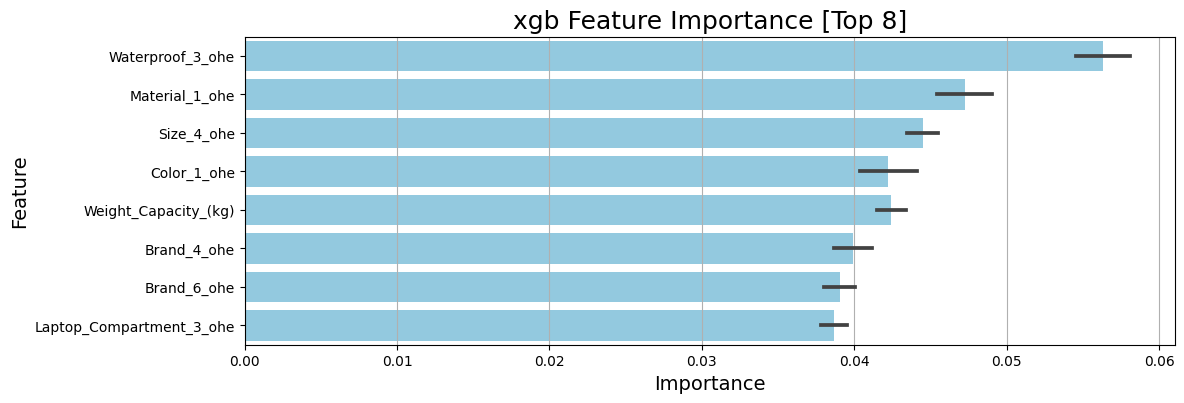

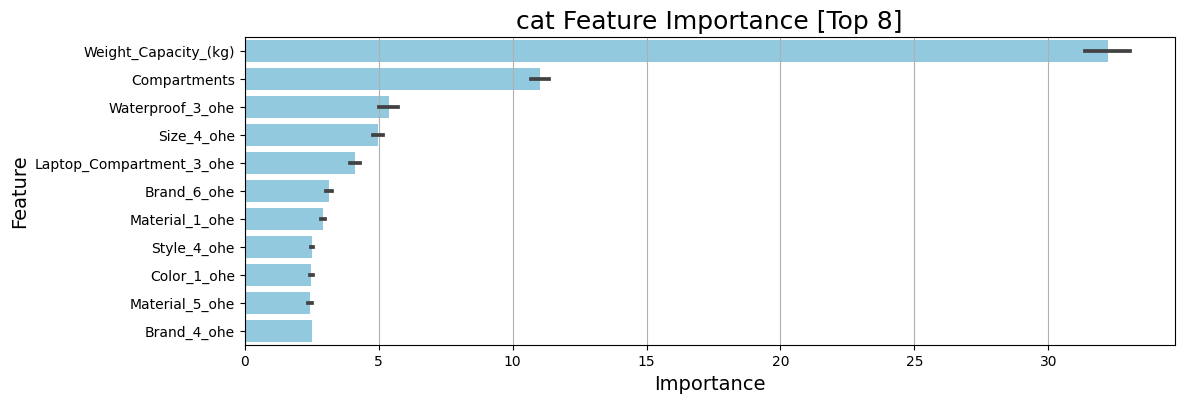

In [42]:
def visualize_importance(models, feature_cols, title, top=8):
    importances = []
    feature_importance = pd.DataFrame()
    for i, model in enumerate(models):
        _df = pd.DataFrame()
        _df["importance"] = model.feature_importances_
        _df["feature"] = pd.Series(feature_cols)
        _df["fold"] = i
        _df = _df.sort_values('importance', ascending=False)
        _df = _df.head(top)
        feature_importance = pd.concat([feature_importance, _df], axis=0, ignore_index=True)
        
    feature_importance = feature_importance.sort_values('importance', ascending=False)
    # display(feature_importance.groupby(["feature"]).mean().reset_index().drop('fold', axis=1))
    plt.figure(figsize=(12, 4))
    sns.barplot(x='importance', y='feature', data=feature_importance, color='skyblue', errorbar='sd')
    plt.xlabel('Importance', fontsize=14)
    plt.ylabel('Feature', fontsize=14)
    plt.title(f'{title} Feature Importance [Top {top}]', fontsize=18)
    plt.grid(True, axis='x')
    plt.show()
    
for name, models in trained_models.items():
    if name in ['cat', 'xgb']:
        visualize_importance(models, list(X_train.columns), name)

# Submission# 

In [43]:
df_sub['Price'] = np.mean(test_predss_sub, axis=0)
df_sub.to_csv('submission.csv',index=False)
df_sub.head(5)

,id,Price
0,300000,80.689592
1,300001,82.627361
2,300002,82.846507
3,300003,80.898821
4,300004,79.181233
